In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [86]:
import math
import random
import pandas as pd

# Set random seed for reproducible results
random.seed(42)

num_samples = 100
data = []

for _ in range(num_samples):
    cgpa = round(random.uniform(5.0, 9.5), 2)
    iq = random.randint(85, 135)

    # Log-odds score (z): Decision boundary centered around CGPA ~7.0 and IQ ~105
    z = 1.5 * (cgpa - 7.0) + 0.08 * (iq - 105)

    # Sigmoid function converting log-odds to probability
    prob = 1 / (1 + math.exp(-z))

    # Binary label based on the 0.5 probability threshold
    placement = 1 if prob >= 0.5 else 0

    data.append({"cgpa": cgpa, "iq": iq, "placement": placement})

df = pd.DataFrame(data)

# Save or inspect dataset
print(df.head(10))
print(f"\nTotal rows: {len(df)}")
print(f"Placement distribution:\n{df['placement'].value_counts()}")

   cgpa   iq  placement
0  7.88   86          0
1  8.34  100          1
2  6.00  132          1
3  5.46  132          0
4  9.01   90          1
5  7.66   87          0
6  5.13   98          0
7  6.05  123          1
8  5.12   97          0
9  8.22  129          1

Total rows: 100
Placement distribution:
placement
1    62
0    38
Name: count, dtype: int64


In [89]:
df.to_csv("placement.csv")

In [115]:
df = pd.read_csv("placement.csv")

In [116]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,7.88,86,0
1,1,8.34,100,1
2,2,6.00,132,1
3,3,5.46,132,0
4,4,9.01,90,1


In [117]:
df.shape

display(df['placement'].value_counts())

display(df.info())

placement
1    62
0    38
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    int64  
 3   placement   100 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 3.3 KB


None

In [118]:
#0. PreProcess + EDA + Feature Selection.
#1. Extract input and output cols 
#2. Scale the values
# 3. Train Test Split
# 4. Train the model
# 5. Evaluate the model/ model selection
# 6.Deploy the model

## 1. PreProcess
Remove the "Unnamed: 0" column

In [119]:
df = df.iloc[:, 1:]

In [120]:
df.head()

,cgpa,iq,placement
0,7.88,86,0
1,8.34,100,1
2,6.00,132,1
3,5.46,132,0
4,9.01,90,1


## 2. EDA
Visulaise our data to understand it.|

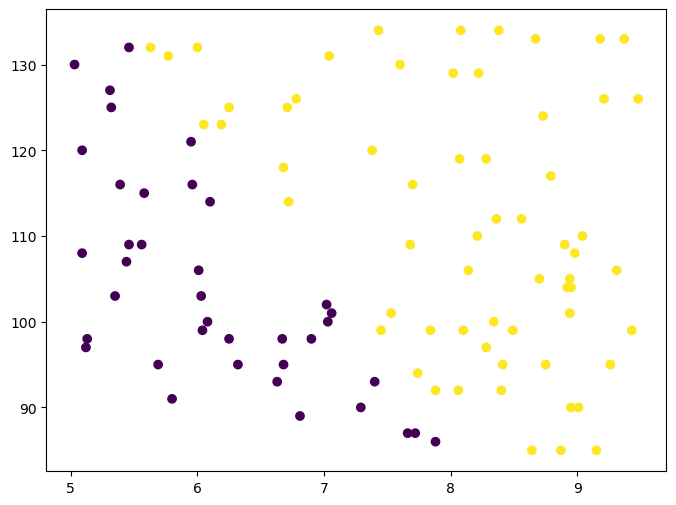

In [121]:
plt.figure(figsize=(8,6)) 
plt.scatter(data = df, x='cgpa', y='iq',c='placement')
plt.show()

Skipped and ignored feature selection step as we only have two columns

In [122]:
X = df.iloc[:,0:2]

In [123]:
y = df.iloc[:, -1]

2. Scale the Values, i will do it after train test split

In [124]:
#Train Test Split
X_train , X_test, y_train, y_test = train_test_split(X,y,test_size=0.1)

In [125]:
y_train

90    1
64    1
15    0
45    1
23    1
     ..
49    1
80    0
69    1
66    0
17    0
Name: placement, Length: 90, dtype: int64

In [126]:
from sklearn.preprocessing import StandardScaler

In [127]:
scaler = StandardScaler()

In [128]:
X_train = scaler.fit_transform(X_train)

In [129]:
X_test = scaler.fit_transform(X_test)

Train the Model

In [130]:
from sklearn.linear_model import LogisticRegression


In [131]:
clf = LogisticRegression()

In [132]:
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [135]:
y_pred = clf.predict(X_test)
y_pred

array([1, 0, 0, 1, 1, 1, 1, 1, 0, 1])

In [136]:
y_test

73    1
95    0
85    0
2     1
54    0
28    1
99    1
44    0
96    0
10    1
Name: placement, dtype: int64

In [137]:
from sklearn.metrics import accuracy_score

In [138]:
accuracy_score(y_test, y_pred)

0.8

In [141]:
!pip install mlxtend

In [142]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

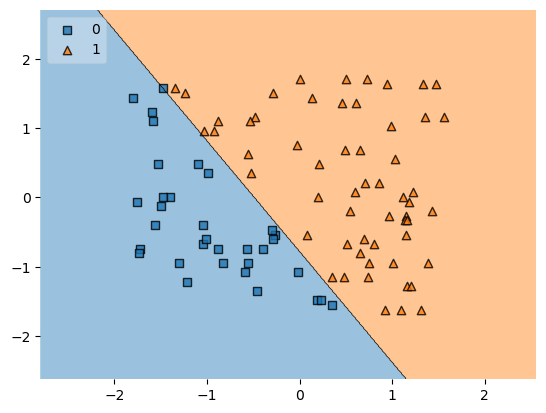

In [144]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [145]:
import pickle

In [146]:
pickle.dump(clf, open('toy_model.pkl', 'wb'))